<a href="https://colab.research.google.com/github/JustinRSK/2025_ML_EES/blob/main/Project/GrandeCaricaie_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# GRANDE CARICAIE - RANDOM FOREST r1 LAND COVER CLASSIFICATION
# Train on all reserves except Cheyres, test on Cheyres
# Keeps all 8 r1 classes
# ============================================================

# -------------------------------
# 0. Install and import packages
# -------------------------------

!pip install -q rasterio scikit-learn joblib pandas matplotlib

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import joblib
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
# -------------------------------
# 1. Define folder and files
# -------------------------------

folder = "/content/drive/MyDrive/GrandeCaricaie_RF"

feature_files = [
    os.path.join(folder, "B2_2056_aligned.tif"),
    os.path.join(folder, "B3_2056_aligned.tif"),
    os.path.join(folder, "B4_2056_aligned.tif"),
    os.path.join(folder, "B8_2056_aligned.tif"),
    os.path.join(folder, "B11_2056_aligned.tif"),
    os.path.join(folder, "NDVI_2056_aligned.tif"),
    os.path.join(folder, "NDWI_2056_aligned.tif")
]

train_label_file = os.path.join(folder, "labels_r1_train_except_Cheyres.tif")
test_label_file = os.path.join(folder, "labels_r1_test_Cheyres.tif")

template_file = feature_files[0]

print("Files in folder:")
print(os.listdir(folder))

Files in folder:
['B3_2056_aligned.tif', 'B2_2056_aligned.tif', 'B11_2056_aligned.tif', 'NDVI_2056_aligned.tif', 'B4_2056_aligned.tif', 'B8_2056_aligned.tif', 'NDWI_2056_aligned.tif', 'labels_r1_train_except_Cheyres.tif', 'labels_r1_test_Cheyres.tif', 'labels_r1_train_except_Cheyres_ALIGNED.tif', 'labels_r1_test_Cheyres_ALIGNED.tif', 'feature_importance_RF_r1_8classes.csv', 'prediction_RF_r1_8classes_full_AOI.tif', 'confidence_RF_r1_8classes_full_AOI.tif', 'uncertainty_RF_r1_8classes_full_AOI.tif']


In [3]:
# -------------------------------
# 2. Check raster dimensions
# -------------------------------

print("Original raster information:")

for file in feature_files + [train_label_file, test_label_file]:
    with rasterio.open(file) as src:
        print(
            os.path.basename(file),
            "shape:", src.shape,
            "crs:", src.crs,
            "resolution:", src.res
        )

Original raster information:
B2_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B3_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B4_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B8_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B11_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
NDVI_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
NDWI_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
labels_r1_train_except_Cheyres.tif shape: (2222, 3206) crs: EPSG:2056 resolution: (10.0, 10.0)
labels_r1_test_Cheyres.tif shape: (290, 421) crs: EPSG:2056 resolution: (10.0, 10.0)


In [4]:
# -------------------------------
# 3. Align labels to the Sentinel raster grid if needed
# -------------------------------

def align_label_to_template(label_file, template_file, output_file):
    with rasterio.open(template_file) as template:
        template_profile = template.profile.copy()
        dst_shape = template.shape
        dst_transform = template.transform
        dst_crs = template.crs

    destination = np.zeros(dst_shape, dtype=np.uint8)

    with rasterio.open(label_file) as src:
        source = src.read(1)

        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata if src.nodata is not None else 0,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            dst_nodata=0,
            resampling=Resampling.nearest
        )

    template_profile.update(
        dtype=rasterio.uint8,
        count=1,
        nodata=0,
        compress="lzw"
    )

    with rasterio.open(output_file, "w", **template_profile) as dst:
        dst.write(destination, 1)

    print("Saved aligned label:", output_file)


train_label_aligned = os.path.join(folder, "labels_r1_train_except_Cheyres_ALIGNED.tif")
test_label_aligned = os.path.join(folder, "labels_r1_test_Cheyres_ALIGNED.tif")

# Always regenerate aligned label rasters to be safe
align_label_to_template(train_label_file, template_file, train_label_aligned)
align_label_to_template(test_label_file, template_file, test_label_aligned)

print("\nAligned raster information:")

for file in feature_files + [train_label_aligned, test_label_aligned]:
    with rasterio.open(file) as src:
        print(
            os.path.basename(file),
            "shape:", src.shape,
            "crs:", src.crs,
            "resolution:", src.res
        )

Saved aligned label: /content/drive/MyDrive/GrandeCaricaie_RF/labels_r1_train_except_Cheyres_ALIGNED.tif


Saved aligned label: /content/drive/MyDrive/GrandeCaricaie_RF/labels_r1_test_Cheyres_ALIGNED.tif

Aligned raster information:
B2_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B3_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B4_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B8_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
B11_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
NDVI_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
NDWI_2056_aligned.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291)
labels_r1_train_except_Cheyres_ALIGNED.tif shape: (3319, 4251) crs: EPSG:2056 resolution: (7.653123100446938, 7.653123109370291

In [5]:
# -------------------------------
# 4. Load and clean feature rasters
# -------------------------------

features = []
feature_names = []

for file in feature_files:
    name = os.path.basename(file).replace(".tif", "")
    feature_names.append(name)

    with rasterio.open(file) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()

        # Convert official NoData to NaN
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        # Remove extreme hidden NoData values
        arr[arr < -1e10] = np.nan
        arr[arr > 1e10] = np.nan

        # Clean vegetation/water indices
        if "NDVI" in name.upper() or "NDWI" in name.upper() or "MNDWI" in name.upper():
            arr[(arr < -1.5) | (arr > 1.5)] = np.nan

        # Clean Sentinel reflectance bands
        else:
            arr[arr < 0] = np.nan

        features.append(arr)

X_stack = np.stack(features, axis=-1)

rows, cols, n_features = X_stack.shape

print("Feature stack shape:", X_stack.shape)
print("Features:", feature_names)

Feature stack shape: (3319, 4251, 7)
Features: ['B2_2056_aligned', 'B3_2056_aligned', 'B4_2056_aligned', 'B8_2056_aligned', 'B11_2056_aligned', 'NDVI_2056_aligned', 'NDWI_2056_aligned']


In [6]:
# -------------------------------
# 5. Load aligned labels
# -------------------------------

with rasterio.open(train_label_aligned) as src:
    y_train_raster = src.read(1)

with rasterio.open(test_label_aligned) as src:
    y_test_raster = src.read(1)

print("Train label shape:", y_train_raster.shape)
print("Test label shape:", y_test_raster.shape)

valid_features = np.all(np.isfinite(X_stack), axis=-1)

train_mask = (y_train_raster > 0) & valid_features
test_mask = (y_test_raster > 0) & valid_features

print("Training pixels:", np.sum(train_mask))
print("Test pixels:", np.sum(test_mask))
print("Training classes:", np.unique(y_train_raster[train_mask]))
print("Test classes:", np.unique(y_test_raster[test_mask]))

Train label shape: (3319, 4251)
Test label shape: (3319, 4251)
Training pixels: 344338
Test pixels: 43399
Training classes: [1 2 3 4 5 6 7 8]
Test classes: [1 2 3 4 5 6 7]


In [7]:
# -------------------------------
# 6. Define class names and inspect class balance
# -------------------------------

class_names = {
    1: "Eaux libres",
    2: "Rivages et lieux humides",
    3: "Pelouses et prairies",
    4: "Milieux construits",
    5: "Plantations champ et culture",
    6: "Glaciers rochers éboulis moraines",
    7: "Forêts",
    8: "Milieux indéterminés"
}

def class_count_table(y, mask, name):
    values, counts = np.unique(y[mask], return_counts=True)

    df = pd.DataFrame({
        "code": values,
        "class": [class_names.get(int(v), "Unknown") for v in values],
        "pixels": counts
    })

    print("\n" + name)
    display(df)

    return df

train_counts = class_count_table(y_train_raster, train_mask, "Training data")
test_counts = class_count_table(y_test_raster, test_mask, "Test data")

train_counts.to_csv(os.path.join(folder, "class_counts_training.csv"), index=False)
test_counts.to_csv(os.path.join(folder, "class_counts_test_Cheyres.csv"), index=False)


Training data


,code,class,pixels
0,1,Eaux libres,128927
1,2,Rivages et lieux humides,99149
2,3,Pelouses et prairies,5687
3,4,Milieux construits,4627
4,5,Plantations champ et culture,2298
5,6,Glaciers rochers éboulis moraines,19
6,7,Forêts,103410
7,8,Milieux indéterminés,221



Test data


,code,class,pixels
0,1,Eaux libres,13084
1,2,Rivages et lieux humides,12393
2,3,Pelouses et prairies,1496
3,4,Milieux construits,614
4,5,Plantations champ et culture,83
5,6,Glaciers rochers éboulis moraines,473
6,7,Forêts,15256


In [8]:
# -------------------------------
# 7. Create balanced training sample
# Keeps all classes, but avoids RAM overload
# -------------------------------

rng = np.random.default_rng(42)

X_2d = X_stack.reshape(-1, n_features)

y_train_flat = y_train_raster.ravel()
y_test_flat = y_test_raster.ravel()

train_mask_flat = train_mask.ravel()
test_mask_flat = test_mask.ravel()

def sample_by_class(y_flat, mask_flat, max_pixels_per_class=8000):
    selected = []

    classes = np.unique(y_flat[mask_flat])

    for c in classes:
        idx = np.where(mask_flat & (y_flat == c))[0]

        if len(idx) > max_pixels_per_class:
            idx = rng.choice(idx, size=max_pixels_per_class, replace=False)

        selected.append(idx)

    selected = np.concatenate(selected)
    rng.shuffle(selected)

    return selected

train_indices = sample_by_class(
    y_train_flat,
    train_mask_flat,
    max_pixels_per_class=8000
)

test_indices = np.where(test_mask_flat)[0]

X_train = X_2d[train_indices]
y_train = y_train_flat[train_indices]

X_test = X_2d[test_indices]
y_test = y_test_flat[test_indices]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Training classes:", np.unique(y_train))
print("Test classes:", np.unique(y_test))

X_train: (36852, 7)
X_test: (43399, 7)
Training classes: [1 2 3 4 5 6 7 8]
Test classes: [1 2 3 4 5 6 7]


In [9]:
# -------------------------------
# 8. Train RAM-safe Random Forest
# -------------------------------

rf = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    max_depth=25,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced_subsample",
    bootstrap=True,
    max_samples=0.7,
    oob_score=True,
    n_jobs=2,
    random_state=42
)

rf.fit(X_train, y_train)

print("OOB score:", rf.oob_score_)

OOB score: 0.7521708455443396


In [10]:
# -------------------------------
# 9. Evaluate on Cheyres test reserve
# -------------------------------

y_pred = rf.predict(X_test)

all_labels = [1, 2, 3, 4, 5, 6, 7, 8]
target_names = [class_names[i] for i in all_labels]

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(
    y_test,
    y_pred,
    labels=all_labels,
    average="macro",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Balanced accuracy:", balanced_accuracy)
print("Macro F1:", macro_f1)

report = classification_report(
    y_test,
    y_pred,
    labels=all_labels,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

report_df.to_csv(os.path.join(folder, "classification_report_RF_r1_8classes_Cheyres.csv"))

cm = confusion_matrix(y_test, y_pred, labels=all_labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {class_names[i]}" for i in all_labels],
    columns=[f"Pred {class_names[i]}" for i in all_labels]
)

display(cm_df)

cm_df.to_csv(os.path.join(folder, "confusion_matrix_RF_r1_8classes_Cheyres.csv"))

Accuracy: 0.7191409940321205
Balanced accuracy: 0.3928957331414446
Macro F1: 0.3282536301327076


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,precision,recall,f1-score,support
Eaux libres,0.910701,0.864415,0.886954,13084.000000
Rivages et lieux humides,0.731242,0.566207,0.638228,12393.000000
Pelouses et prairies,0.168092,0.302139,0.216010,1496.000000
Milieux construits,0.075402,0.198697,0.109319,614.000000
Plantations champ et culture,0.003401,0.012048,0.005305,83.000000
Glaciers rochers éboulis moraines,0.000000,0.000000,0.000000,473.000000
Forêts,0.736830,0.806765,0.770213,15256.000000
Milieux indéterminés,0.000000,0.000000,0.000000,0.000000
accuracy,0.719141,0.719141,0.719141,0.719141
macro avg,0.328209,0.343784,0.328254,43399.000000


,Pred Eaux libres,Pred Rivages et lieux humides,Pred Pelouses et prairies,Pred Milieux construits,Pred Plantations champ et culture,Pred Glaciers rochers éboulis moraines,Pred Forêts,Pred Milieux indéterminés
True Eaux libres,11310,1063,63,320,7,0,319,2
True Rivages et lieux humides,852,7017,854,523,143,0,2991,13
True Pelouses et prairies,0,289,452,164,48,0,540,3
True Milieux construits,7,161,112,122,12,0,199,1
True Plantations champ et culture,0,18,24,12,1,0,28,0
True Glaciers rochers éboulis moraines,1,20,92,38,3,0,319,0
True Forêts,249,1028,1092,439,80,0,12308,60
True Milieux indéterminés,0,0,0,0,0,0,0,0


,feature,importance
4,B11_2056_aligned,0.195748
6,NDWI_2056_aligned,0.144966
3,B8_2056_aligned,0.139837
5,NDVI_2056_aligned,0.139195
2,B4_2056_aligned,0.136204
0,B2_2056_aligned,0.130441
1,B3_2056_aligned,0.113609


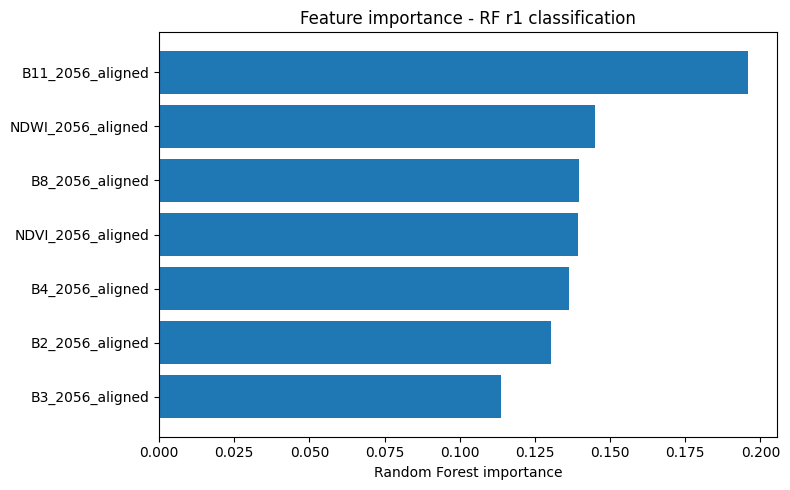

In [11]:
# -------------------------------
# 10. Feature importance
# -------------------------------

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

importance_df.to_csv(
    os.path.join(folder, "feature_importance_RF_r1_8classes.csv"),
    index=False
)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest importance")
plt.title("Feature importance - RF r1 classification")
plt.tight_layout()

plt.savefig(os.path.join(folder, "feature_importance_RF_r1_8classes.png"), dpi=300)
plt.show()

In [12]:
# -------------------------------
# 11. Save trained model
# -------------------------------

model_path = os.path.join(folder, "RF_r1_8classes_except_Cheyres.joblib")

joblib.dump(rf, model_path)

print("Saved model:", model_path)

Saved model: /content/drive/MyDrive/GrandeCaricaie_RF/RF_r1_8classes_except_Cheyres.joblib


In [13]:
# -------------------------------
# 12. Predict full AOI in chunks
# Avoids RAM crash
# -------------------------------

prediction_flat = np.zeros(X_2d.shape[0], dtype=np.uint8)
confidence_flat = np.zeros(X_2d.shape[0], dtype=np.float32)

valid_flat = valid_features.ravel()
valid_indices = np.where(valid_flat)[0]

print("Valid pixels to predict:", len(valid_indices))

chunk_size = 100000

for start in range(0, len(valid_indices), chunk_size):
    end = start + chunk_size
    idx = valid_indices[start:end]

    proba = rf.predict_proba(X_2d[idx])
    best_idx = np.argmax(proba, axis=1)

    prediction_flat[idx] = rf.classes_[best_idx].astype(np.uint8)
    confidence_flat[idx] = np.max(proba, axis=1).astype(np.float32)

    print(f"Predicted {min(end, len(valid_indices))} / {len(valid_indices)} pixels")

prediction_raster = prediction_flat.reshape(rows, cols)
confidence_raster = confidence_flat.reshape(rows, cols)
uncertainty_raster = np.where(confidence_raster > 0, 1 - confidence_raster, 0)

print("Prediction complete.")

Valid pixels to predict: 444855
Predicted 100000 / 444855 pixels
Predicted 200000 / 444855 pixels
Predicted 300000 / 444855 pixels
Predicted 400000 / 444855 pixels
Predicted 444855 / 444855 pixels
Prediction complete.


In [14]:
# -------------------------------
# 13. Save prediction, confidence, uncertainty rasters for QGIS
# -------------------------------

pred_profile = profile.copy()
pred_profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw"
)

prediction_path = os.path.join(folder, "prediction_RF_r1_8classes_full_AOI.tif")

with rasterio.open(prediction_path, "w", **pred_profile) as dst:
    dst.write(prediction_raster, 1)


prob_profile = profile.copy()
prob_profile.update(
    dtype=rasterio.float32,
    count=1,
    nodata=0,
    compress="lzw"
)

confidence_path = os.path.join(folder, "confidence_RF_r1_8classes_full_AOI.tif")
uncertainty_path = os.path.join(folder, "uncertainty_RF_r1_8classes_full_AOI.tif")

with rasterio.open(confidence_path, "w", **prob_profile) as dst:
    dst.write(confidence_raster.astype("float32"), 1)

with rasterio.open(uncertainty_path, "w", **prob_profile) as dst:
    dst.write(uncertainty_raster.astype("float32"), 1)

print("Saved QGIS rasters:")
print(prediction_path)
print(confidence_path)
print(uncertainty_path)

Saved QGIS rasters:
/content/drive/MyDrive/GrandeCaricaie_RF/prediction_RF_r1_8classes_full_AOI.tif
/content/drive/MyDrive/GrandeCaricaie_RF/confidence_RF_r1_8classes_full_AOI.tif
/content/drive/MyDrive/GrandeCaricaie_RF/uncertainty_RF_r1_8classes_full_AOI.tif


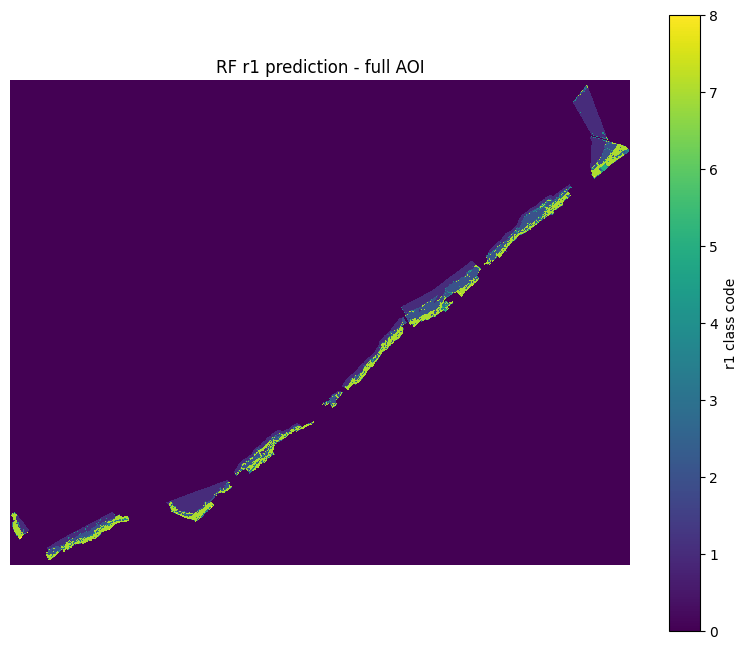

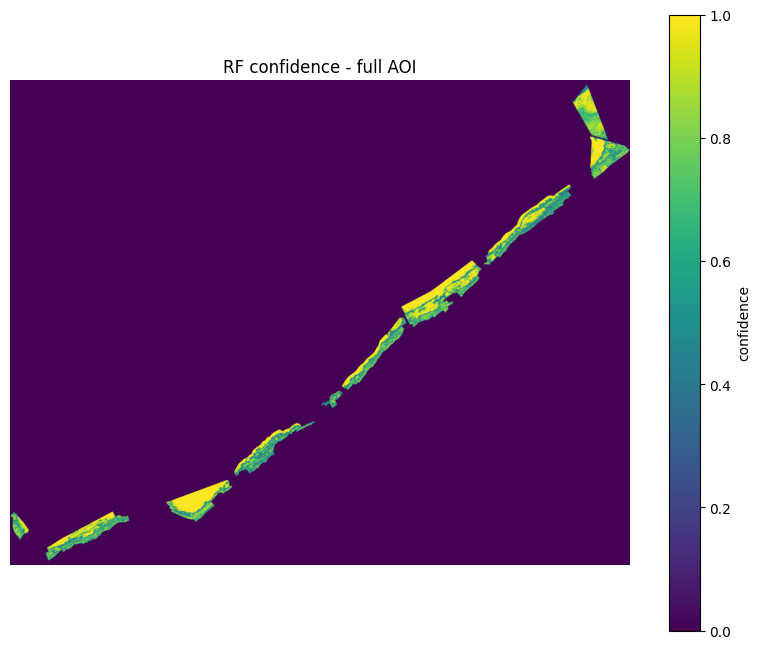

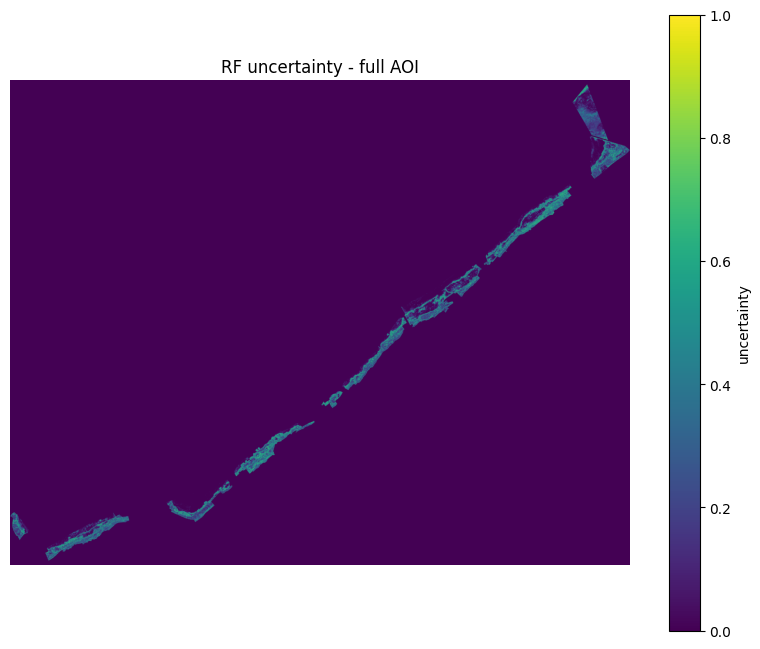

In [15]:
# -------------------------------
# 14. Quick visual check in Colab
# -------------------------------

plt.figure(figsize=(10, 8))
plt.imshow(prediction_raster, interpolation="nearest")
plt.title("RF r1 prediction - full AOI")
plt.colorbar(label="r1 class code")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(confidence_raster, vmin=0, vmax=1)
plt.title("RF confidence - full AOI")
plt.colorbar(label="confidence")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(uncertainty_raster, vmin=0, vmax=1)
plt.title("RF uncertainty - full AOI")
plt.colorbar(label="uncertainty")
plt.axis("off")
plt.show()

In [16]:
import os
import numpy as np
import rasterio
from scipy.ndimage import generic_filter
from scipy import stats

folder = "/content/drive/MyDrive/GrandeCaricaie_RF"

input_prediction = os.path.join(folder, "prediction_RF_r1_8classes_full_AOI.tif")
output_majority = os.path.join(folder, "prediction_RF_r1_8classes_majority_3x3.tif")

def majority_filter(values):
    values = values.astype(np.uint8)

    # Ignore NoData/background = 0
    values = values[values > 0]

    if len(values) == 0:
        return 0

    # Return most frequent class
    return stats.mode(values, keepdims=False).mode

with rasterio.open(input_prediction) as src:
    pred = src.read(1).astype(np.uint8)
    profile = src.profile.copy()

majority = generic_filter(
    pred,
    function=majority_filter,
    size=3,
    mode="constant",
    cval=0
).astype(np.uint8)

# Safety check: force impossible values to 0
majority[~np.isin(majority, [0, 1, 2, 3, 4, 5, 6, 7, 8])] = 0

profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw"
)

with rasterio.open(output_majority, "w", **profile) as dst:
    dst.write(majority, 1)

print("Saved:", output_majority)
print("Unique values:", np.unique(majority))

Saved: /content/drive/MyDrive/GrandeCaricaie_RF/prediction_RF_r1_8classes_majority_3x3.tif
Unique values: [0 1 2 3 4 5 6 7 8]
